# Bias–Variance Decomposition: смещение, разброс и MSE

Почему несмещённая модель может предсказывать хуже смещённой? Почему более глубокое дерево иногда проигрывает мелкому? Этот ноутбук разбирает **разложение ожидаемой квадратичной ошибки (BVD)**: от вывода до формул для OLS, Ridge, Lasso и деревьев регрессии. На синтетических данных известна истинная функция — поэтому можно измерить компоненты ошибки по отдельности.

Продолжение [линейной регрессии](linearregression.ipynb), [деревьев решений](decisiontrees.ipynb) и раздела BVD в [случайном лесе](randomforest.ipynb).

**Содержание:**
1. Что случайно и что мы предсказываем
2. Вывод разложения MSE
3. Как измерять BVD в эксперименте
4. OLS и теорема Гаусса — Маркова
5. Ridge: точные bias и variance
6. Lasso: точное разложение при ортогональных признаках
7. Эксперимент: регуляризация и trade-off
8. Деревья: фиксированные листья и адаптивные разбиения
9. Эксперимент: глубина дерева и trade-off
10. Практические выводы

## 1. Что случайно и что мы предсказываем

Пусть $D=\{(x_i,y_i)\}_{i=1}^n$ — случайная обучающая выборка, а $\hat f_D$ — результат **всей процедуры обучения**. В общем случае в $D$ условно включаем и случайность алгоритма. Рассматриваем новое наблюдение, независимое от обучения:

$$y=f(x)+\varepsilon,\qquad f(x)=\mathbb E[y\mid x],\qquad
\mathbb E[\varepsilon\mid x]=0,\quad \operatorname{Var}(\varepsilon\mid x)=\sigma^2(x).$$

Для примеров упростим: $\varepsilon\sim\mathcal N(0,\sigma^2)$ независимо от признаков и других шумов. **Для самого BVD нормальность и постоянная дисперсия не нужны**: достаточно конечных вторых моментов, нулевого условного среднего шума и независимости нового наблюдения от обучения.

При фиксированном $x$ определим:

$$\bar f(x)=\mathbb E_D[\hat f_D(x)],\qquad
b(x)=\bar f(x)-f(x),\qquad
v(x)=\mathbb E_D[(\hat f_D(x)-\bar f(x))^2].$$

- **Смещение (bias)** — систематическое отклонение среднего по переобучениям прогноза от истины. В MSE входит **квадрат** смещения.
- **Разброс (variance, дисперсия)** — изменчивость прогноза в одной и той же точке при замене обучающей выборки.
- **Неустранимый шум** — вариативность нового $y$ даже при известном $f(x)$; «неустранимый» относительно доступных признаков и выбранной постановки.

Разброс — это не дисперсия предсказаний по разным объектам и не дисперсия остатков одной модели. Свободный член, который в коде иногда называют `bias`, тоже не является смещением в BVD.

## 2. Вывод разложения MSE

Добавим и вычтем средний прогноз:

$$y-\hat f_D(x)=\underbrace{f(x)-\bar f(x)}_{-b(x)}
+\underbrace{\bar f(x)-\hat f_D(x)}_{\text{среднее равно нулю}}
+\varepsilon.$$

После возведения в квадрат и усреднения все перекрёстные члены исчезают: центрированное предсказание имеет среднее ноль, а новый шум имеет среднее ноль и независим от обучения. Поэтому

$$\boxed{\mathbb E_{D,\varepsilon}[(y-\hat f_D(x))^2\mid x]
=b(x)^2+v(x)+\sigma^2(x).}$$

Усреднение по распределению **новых** признаков даёт ожидаемый test MSE:

$$R=\mathbb E_x[b(x)^2]+\mathbb E_x[v(x)]+\mathbb E_x[\sigma^2(x)].$$

Здесь $\mathbb E_x[b(x)^2]\ne(\mathbb E_x[b(x)])^2$: положительные и отрицательные смещения не должны взаимно уничтожаться.

Если предсказываем саму функцию $f(x)$, а не шумное наблюдение $y$, слагаемого $\sigma^2(x)$ нет. Для ошибки на обучающих объектах приведённый вывод неприменим: их шум уже участвовал в построении $\hat f_D$. Для MAE и 0–1 ошибки классификации это тождество также нельзя переносить напрямую.

### Bias–variance trade-off

Повышение гибкости часто уменьшает смещение, но увеличивает разброс. Регуляризация часто действует в обратную сторону. Выбирать нужно минимум **суммы**, а не минимум одного компонента. Это типичная картина, а не закон монотонности и не требование U-образной кривой для любой модели: например, при интерполяции возможен double descent.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from IPython.display import display

plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.grid": True,
                     "grid.alpha": 0.25, "font.size": 11})

## 3. Как измерять BVD в эксперименте

Обучаем алгоритм на $B$ независимых выборках одинакового размера. В каждой фиксированной тестовой точке $x_j$ сохраняем прогнозы $p_{bj}$. Затем считаем

$$\bar p_j=\frac1B\sum_b p_{bj},\quad
\widehat{b^2}_j=(\bar p_j-f(x_j))^2,\quad
\hat v_j=\frac1B\sum_b(p_{bj}-\bar p_j)^2.$$

При делителе $B$ (`ddof=0`) выполняется **точное эмпирическое тождество**:

$$\frac1B\sum_b(p_{bj}-f(x_j))^2=\widehat{b^2}_j+\hat v_j.$$

При конечном $B$ это оценки популяционных компонентов: $\widehat{b^2}$ в среднем завышено на $v/B$, а $\hat v$ занижено на $v/B$. Их сумма корректно оценивает риск относительно $f$. Делитель $B-1$ исправляет оценку variance, но тогда для сохранения тождества надо скорректировать и bias². В учебных графиках используем `ddof=0` и достаточно много повторов.

Одного train/test split недостаточно для такого измерения. На реальных данных неизвестны $f$ и шум; cross-validation оценивает общую ошибку, но не разделяет её автоматически на три компонента. Повторный bootstrap одной выборки тоже не равен генерации независимых выборок из истинного распределения.

In [4]:
def estimate_bvd(predictions, truth, noise_variance):
    """predictions: (число переобучений, число тестовых точек)."""
    mean_prediction = predictions.mean(axis=0)
    bias2 = (mean_prediction - truth) ** 2
    variance = predictions.var(axis=0, ddof=0)
    error_to_f = ((predictions - truth) ** 2).mean(axis=0)
    np.testing.assert_allclose(error_to_f, bias2 + variance, atol=1e-12)
    return {"bias2": bias2.mean(), "variance": variance.mean(),
            "noise": noise_variance,
            "expected_mse": error_to_f.mean() + noise_variance}

## 4. OLS и теорема Гаусса — Маркова

### 4.1. Предпосылки и BVD обычной линейной регрессии

Теперь **фиксируем** матрицу обучения $X\in\mathbb R^{n\times p}$ и рассматриваем правильно заданную линейную модель:

$$y=X\beta+\varepsilon,\qquad \operatorname{rank}(X)=p,\qquad
\mathbb E[\varepsilon\mid X]=0,\qquad
\operatorname{Cov}(\varepsilon\mid X)=\sigma^2I_n.$$

Последнее условие означает одинаковую дисперсию и отсутствие корреляции ошибок. Нормальность не требуется. Полный ранг запрещает **точную** линейную зависимость столбцов; сильная, но не точная мультиколлинеарность не нарушает теорему, хотя увеличивает дисперсию оценок. Далее для простоты считаем свободный член известным и равным нулю; если его оценивают, нужно учесть и его неопределённость.

Для $S=X^TX$:

$$\hat\beta_{OLS}=S^{-1}X^Ty,\qquad
\mathbb E[\hat\beta_{OLS}\mid X]=\beta,\qquad
\operatorname{Cov}(\hat\beta_{OLS}\mid X)=\sigma^2S^{-1}.$$

В новой фиксированной точке $x_0$ получаем

$$\boxed{R_{OLS}(x_0\mid X)=0+\sigma^2x_0^TS^{-1}x_0+\sigma^2.}$$

Нулевое смещение здесь следует из правильной спецификации модели. Если истинная зависимость нелинейна в используемых признаках, такой вывод уже не действует.

### 4.2. Формулировка и короткое доказательство

**Теорема Гаусса — Маркова:** при перечисленных условиях OLS — BLUE (Best Linear Unbiased Estimator): оценка с минимальной ковариационной матрицей среди оценок коэффициентов, линейных **по $y$** и несмещённых для всех $\beta$.

Пусть другая оценка равна $Ay$ и $AX=I_p$. Представим $A=S^{-1}X^T+C$, тогда $CX=0$. Перекрёстные члены ковариации исчезают:

$$\operatorname{Cov}(Ay\mid X)
=\sigma^2S^{-1}+\sigma^2CC^T
\succeq\operatorname{Cov}(\hat\beta_{OLS}\mid X).$$

Матрица $CC^T$ положительно полуопределена: для любого $a$ имеем $a^TCC^Ta=\|C^Ta\|^2\ge0$. Значит, OLS минимизирует дисперсию любой линейной комбинации коэффициентов в этом классе.

**Почему Ridge может быть лучше?** Теорема ограничивает класс сравнения несмещёнными линейными оценками. Ridge допускает смещение и может выиграть по MSE, уменьшив variance сильнее, чем увеличил bias². Теорема не обещает минимальный test MSE среди всех алгоритмов.

В другом конспекте условия уже упомянуты: [«Линейная регрессия», §11 «Диагностика обученной модели»](linearregression.ipynb#11.-Диагностика-обученной-модели). Там дано краткое упоминание условий, а формулировка и доказательство приведены здесь. Дополнительное изложение: [Marco Taboga, Gauss–Markov theorem](https://www.statlect.com/fundamentals-of-statistics/Gauss-Markov-theorem).

## 5. Ridge: точные bias и variance

Зафиксируем масштаб штрафа:

$$\hat\beta_\lambda=\arg\min_b\{\|y-Xb\|^2+\lambda\|b\|^2\}
=(S+\lambda I)^{-1}X^Ty,\qquad\lambda\ge0.$$

Это соглашение соответствует `Ridge(alpha=lambda, fit_intercept=False)`. Обозначим $A_\lambda=(S+\lambda I)^{-1}$. Из линейности оценки по $y$:

$$\mathbb E[\hat\beta_\lambda\mid X]-\beta=-\lambda A_\lambda\beta,\qquad
\operatorname{Cov}(\hat\beta_\lambda\mid X)=\sigma^2A_\lambda S A_\lambda.$$

Поэтому **для прогноза**, а не для вектора коэффициентов:

$$\boxed{R_{Ridge}(x_0\mid X)=
\lambda^2(x_0^TA_\lambda\beta)^2+
\sigma^2x_0^TA_\lambda S A_\lambda x_0+\sigma^2.}$$

При $S=Q\operatorname{diag}(d_j)Q^T$ положим $\tilde\beta=Q^T\beta$, $\tilde x_0=Q^Tx_0$. Тогда

$$b(x_0)=-\sum_j\tilde x_{0j}\frac{\lambda}{d_j+\lambda}\tilde\beta_j,
\qquad v(x_0)=\sigma^2\sum_j\tilde x_{0j}^2\frac{d_j}{(d_j+\lambda)^2}.$$

Малые $d_j$ делают OLS нестабильным; Ridge особенно сильно сжимает эти направления. При фиксированном $X$ variance прогноза не возрастает с $\lambda$. Но квадрат смещения **в отдельной точке** не обязан расти монотонно: слагаемые могут компенсировать друг друга.

При $\lambda=0$ возвращаемся к OLS; при $\lambda\to\infty$ прогноз стремится к нулю, variance — к нулю, bias² — к $f(x_0)^2$. Эти пределы относятся к модели без свободного члена. В обычной практике свободный член не штрафуют, а признаки масштабируют по обучающей выборке.

### Фиксированные и случайные признаки

Формулы выше усредняют только шум обучения при данном $X$. Если каждый раз генерировать и $X$, нужно применить закон полной дисперсии:

$$\operatorname{Var}_D(\hat f_D(x_0))=
\mathbb E_X[\operatorname{Var}(\hat f_D(x_0)\mid X)]
+\operatorname{Var}_X(\mathbb E[\hat f_D(x_0)\mid X]).$$

Нельзя просто назвать условную variance полной. Среднее смещение также сначала усредняется по $X$, а затем возводится в квадрат.

## 6. Lasso: точное разложение при ортогональных признаках

У Lasso штраф другой, и договорённость о масштабе тоже другая:

$$\hat\beta_\alpha=\arg\min_b\left\{\frac{1}{2n}\|y-Xb\|^2+\alpha\|b\|_1\right\}.$$

Это `Lasso(alpha=alpha, fit_intercept=False)`. В общем случае Lasso нелинеен по $y$, и простой матричной формулы ковариации, как у Ridge, нет. Для точного учебного примера предположим

$$X^TX=nI_p,\qquad \varepsilon\sim\mathcal N(0,\sigma^2 I_n),\qquad n\ge p.$$

Тогда $Z_j=\hat\beta_{OLS,j}\sim\mathcal N(\beta_j,\tau^2)$, где $\tau^2=\sigma^2/n$, и $Z_j$ независимы. Задача распадается по координатам: минимизируем $\frac12(b_j-Z_j)^2+\alpha|b_j|$. Производная на положительной/отрицательной полуоси и условие в нуле дают **мягкое пороговое преобразование (soft thresholding)**:

$$\hat\beta_{\alpha,j}=S_\alpha(Z_j)=\operatorname{sign}(Z_j)(|Z_j|-\alpha)_+.$$

Коэффициент становится ровно нулём, если $|Z_j|\le\alpha$. Нормальность нужна здесь для явных моментов и независимости координат, но не для самого soft thresholding.

### 6.1. Моменты одного коэффициента

Пусть $Z\sim\mathcal N(\mu,\tau^2)$, $a=(\alpha-\mu)/\tau$, $c=(-\alpha-\mu)/\tau$, а $\phi,\Phi$ — плотность и функция распределения стандартной нормали. Интегрируя отдельно области $Z>\alpha$ и $Z<-\alpha$, получим

$$m=\mathbb E[S_\alpha(Z)]
=(\mu-\alpha)[1-\Phi(a)]+\tau\phi(a)
+(\mu+\alpha)\Phi(c)-\tau\phi(c),$$

$$q=\mathbb E[S_\alpha(Z)^2]
=[(\mu-\alpha)^2+\tau^2][1-\Phi(a)]+\tau(\mu-\alpha)\phi(a)
+[(\mu+\alpha)^2+\tau^2]\Phi(c)-\tau(\mu+\alpha)\phi(c).$$

Тогда bias коэффициента равен $m-\mu$, variance — $q-m^2$. Для новой точки, благодаря независимости координат,

$$\boxed{R_{Lasso}(x_0\mid X)=
\left[\sum_jx_{0j}(m_j-\beta_j)\right]^2+
\sum_jx_{0j}^2(q_j-m_j^2)+\sigma^2.}$$

При $\alpha=0$ имеем $m_j=\beta_j$, $q_j-m_j^2=\tau^2$. При $\alpha\to\infty$ все коэффициенты стремятся к нулю. Для $\beta_j=0$ смещение остаётся нулевым по симметрии, а разброс сокращается: это объясняет пользу Lasso при разреженном сигнале. Ненулевые коэффициенты сжимаются и получают смещение.

При коррелированных признаках коэффициенты уже зависимы, в variance прогноза нужны ковариационные члены. Ортогональные формулы туда переносить нельзя; ортогонализация также меняет смысл L1-штрафа и разреженности в исходном базисе.

In [5]:
def lasso_moments(mu, tau, alpha):
    a = (alpha - mu) / tau
    c = (-alpha - mu) / tau
    m = ((mu - alpha) * norm.sf(a) + tau * norm.pdf(a)
         + (mu + alpha) * norm.cdf(c) - tau * norm.pdf(c))
    q = (((mu - alpha)**2 + tau**2) * norm.sf(a)
         + tau * (mu - alpha) * norm.pdf(a)
         + ((mu + alpha)**2 + tau**2) * norm.cdf(c)
         - tau * (mu + alpha) * norm.pdf(c))
    return m, np.maximum(q - m**2, 0.0)  # защита от округления около нуля

## 7. Эксперимент: регуляризация и trade-off

Возьмём фиксированный ортогональный дизайн, $n=60$, $p=20$, только три ненулевых коэффициента и $\sigma=1$. Новые признаки распределены как $x_0\sim\mathcal N(0,I_p)$ независимо от обучения. Тогда $\mathbb E[x_0x_0^T]=I_p$, поэтому интегральные bias² и variance равны соответственно **сумме квадратов смещений коэффициентов** и **следу их ковариации**.

Для Ridge обозначим $t=\lambda/n$. При таком дизайне $\hat\beta_{Ridge}=Z/(1+t)$, и

$$R_{Ridge}(t)=\left(\frac{t}{1+t}\right)^2\|\beta\|^2
+\frac{p\sigma^2}{n(1+t)^2}+\sigma^2.$$

Минимум достигается при $t^*=p\sigma^2/(n\|\beta\|^2)$ для ненулевой $\beta$. Это иллюстрация выигрыша смещённой оценки над BLUE по MSE. В реальной задаче $\beta$ неизвестна — формула не заменяет валидацию.

Сравним точную теорию с 12 000 независимыми реализациями OLS-статистики $Z$. Это эквивалентно перегенерации гауссовского шума при данном $X$, но быстрее полного переобучения. Отдельно проверим решения через scikit-learn. Оси Ridge и Lasso имеют разные смыслы: одинаковые численные значения их параметров не означают одинаковую силу штрафа.

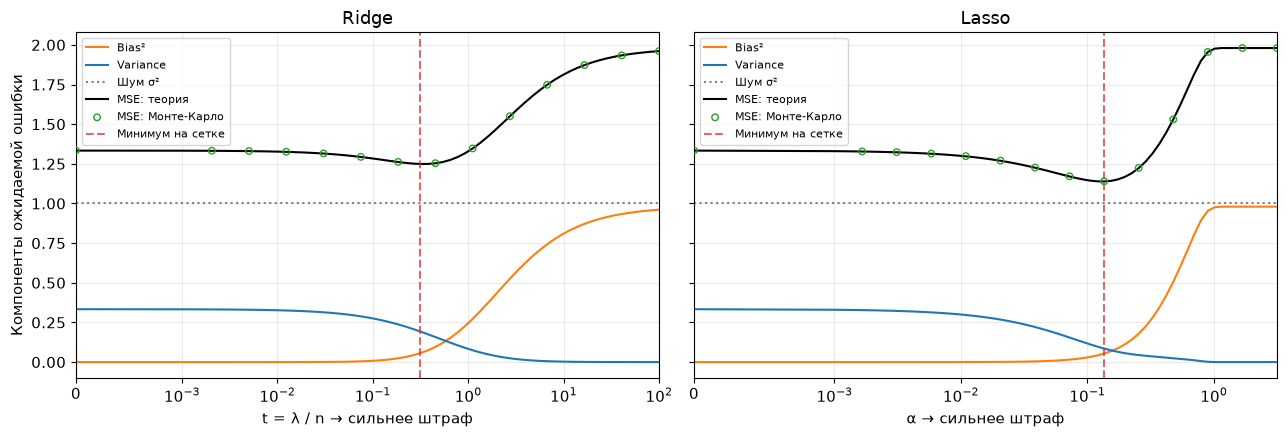

,Модель,Параметр на сетке,Bias²,Variance,MSE теория,MSE Монте-Карло,MSE OLS
0,Ridge,0.3162,0.0566,0.1924,1.2490,1.2497,1.3333
1,Lasso,0.1358,0.0536,0.0852,1.1388,1.1398,1.3333


Точный оптимум Ridge t*: 0.3401
Максимальное расхождение MSE теории и Монте-Карло: 0.0011


In [6]:
rng_linear = np.random.default_rng(42)
n, p, sigma_linear = 60, 20, 1.0
beta = np.zeros(p)
beta[:3] = [0.8, -0.5, 0.3]
tau = sigma_linear / np.sqrt(n)
Q, _ = np.linalg.qr(rng_linear.normal(size=(n, p)))
X_linear = np.sqrt(n) * Q
y_linear = X_linear @ beta + rng_linear.normal(0, sigma_linear, n)
z_check = X_linear.T @ y_linear / n
np.testing.assert_allclose(X_linear.T @ X_linear, n * np.eye(p), atol=1e-12)
np.testing.assert_allclose(
    Ridge(alpha=n * 0.3, fit_intercept=False).fit(X_linear, y_linear).coef_,
    z_check / 1.3, atol=1e-10)
np.testing.assert_allclose(
    Lasso(alpha=0.1, fit_intercept=False, tol=1e-12, max_iter=10000)
        .fit(X_linear, y_linear).coef_,
    np.sign(z_check) * np.maximum(np.abs(z_check) - 0.1, 0), atol=1e-10)
m0, v0 = lasso_moments(beta, tau, 0)
np.testing.assert_allclose(m0, beta, atol=1e-12)
np.testing.assert_allclose(v0, tau**2, atol=1e-12)

Z = beta + rng_linear.normal(0, tau, size=(12000, p))
ridge_grid = np.r_[0, np.logspace(-3, 2, 65)]
lasso_grid = np.r_[0, np.logspace(-3, 0.5, 65)]
linear_results = {}
for name, grid in [("Ridge", ridge_grid), ("Lasso", lasso_grid)]:
    rows = []
    for value in grid:
        if name == "Ridge":
            mean = beta / (1 + value)
            var = np.full(p, tau**2 / (1 + value)**2)
            samples = Z / (1 + value)
        else:
            mean, var = lasso_moments(beta, tau, value)
            samples = np.sign(Z) * np.maximum(np.abs(Z) - value, 0)
        bias2 = np.sum((mean - beta)**2)
        variance = var.sum()
        # E_x[(x @ (beta_hat-beta))²] = ||beta_hat-beta||² при E[xx^T]=I.
        mse_mc = np.mean(np.sum((samples - beta)**2, axis=1)) + sigma_linear**2
        rows.append([value, bias2, variance, bias2 + variance + sigma_linear**2, mse_mc])
    linear_results[name] = pd.DataFrame(
        rows, columns=["parameter", "bias2", "variance", "mse_theory", "mse_mc"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (name, result) in zip(axes, linear_results.items()):
    x = result.parameter
    ax.plot(x, result.bias2, label="Bias²", color="tab:orange")
    ax.plot(x, result.variance, label="Variance", color="tab:blue")
    ax.axhline(sigma_linear**2, color="gray", ls=":", label="Шум σ²")
    ax.plot(x, result.mse_theory, color="black", label="MSE: теория")
    ax.scatter(x[::5], result.mse_mc[::5], s=22, facecolors="none",
               edgecolors="tab:green", label="MSE: Монте-Карло", zorder=4)
    best = result.loc[result.mse_theory.idxmin()]
    ax.axvline(best.parameter, color="tab:red", ls="--", alpha=0.7, label="Минимум на сетке")
    ax.set_xscale("symlog", linthresh=0.001)
    ax.set_xlim(0, x.iloc[-1])
    ax.set_xlabel("t = λ / n → сильнее штраф" if name == "Ridge" else "α → сильнее штраф")
    ax.set_title(name)
    ax.legend(fontsize=8)
axes[0].set_ylabel("Компоненты ожидаемой ошибки")
plt.tight_layout()
plt.show()

comparison = []
for name, result in linear_results.items():
    best = result.loc[result.mse_theory.idxmin()]
    comparison.append({"Модель": name, "Параметр на сетке": best.parameter,
                       "Bias²": best.bias2, "Variance": best.variance,
                       "MSE теория": best.mse_theory, "MSE Монте-Карло": best.mse_mc,
                       "MSE OLS": result.mse_theory.iloc[0]})
display(pd.DataFrame(comparison).round(4))
print("Точный оптимум Ridge t*:", round(p * tau**2 / np.dot(beta, beta), 4))
print("Максимальное расхождение MSE теории и Монте-Карло:",
      round(max((r.mse_theory - r.mse_mc).abs().max() for r in linear_results.values()), 4))

При нулевом штрафе обе модели совпадают с OLS: bias² равен нулю, но variance положительна. Умеренный штраф уменьшает суммарную ошибку; слишком сильный уничтожает сигнал. В этой разреженной постановке Lasso может выигрывать за счёт подавления лишних координат. Это не универсальный рейтинг: результат изменится при плотном сигнале, корреляциях и другом отношении шума к сигналу.

Кружки показывают риск, независимо вычисленный через ошибки коэффициентов в Монте-Карло. Его отличие от точной кривой связано с конечным числом повторов. Выделенный минимум использует известную истину и служит учебным ориентиром, а не результатом подбора на реальных данных.

## 8. Деревья: фиксированные листья и адаптивные разбиения

### 8.1. Простая точная формула для заранее заданных листьев

Дерево регрессии со squared-error критерием предсказывает среднее $y_i$ в листе. Для начала пусть разбиение на листья задано **до наблюдения обучающих ответов**, $X$ фиксирован, в листе $L(x_0)$ есть $n_L>0$ объектов и независимый шум имеет дисперсию $\sigma^2$. Тогда

$$\hat f(x_0)=\frac1{n_L}\sum_{i:x_i\in L(x_0)}y_i,\qquad
\bar f_L=\frac1{n_L}\sum_{i:x_i\in L(x_0)}f(x_i).$$

Следовательно,

$$\boxed{R_{\text{fixed leaves}}(x_0\mid X)
=(\bar f_L-f(x_0))^2+\frac{\sigma^2}{n_L}+\sigma^2.}$$

Крупный лист усредняет много шумов и имеет малую variance, но заменяет изменяющуюся функцию одной константой. Мелкие листья обычно лучше приближают функцию, но опираются на меньшее число наблюдений. Например, при $\sigma=0.4$ вклад шума обучения равен $0.16$ для одного объекта и $0.016$ для десяти; шум **нового** ответа остаётся $0.16$ в обоих случаях.

Если признаки в листе случайны, при фиксированном разбиении и условии $N_L=k>0$:

$$\operatorname{Var}(\hat f_L\mid N_L=k)
=\frac{\operatorname{Var}(f(x)\mid x\in L)+\sigma^2}{k}.$$

Появилась ещё вариативность истинной функции внутри листа. Поэтому даже для заранее заданных листьев $\sigma^2/n_L$ не описывает всю дисперсию при случайном дизайне.

### 8.2. Обычный CART выбирает разбиения по тем же ответам

У обучаемого дерева случайны пороги, признаки разбиения, состав листьев и их размеры. Малое изменение выборки может перестроить верхний узел и множество последующих прогнозов. Условиться на уже выбранное по $y$ разбиение и считать шум независимым по-прежнему нельзя: выбор разбиения зависит от него.

Общее BVD при этом остаётся точным:

$$R_{tree}(x_0)=\big(\mathbb E_D[\hat f_D(x_0)]-f(x_0)\big)^2
+\operatorname{Var}_D(\hat f_D(x_0))+\sigma^2.$$

Для случайного разбиения $T$ также верен закон полной дисперсии:

$$\operatorname{Var}_D(\hat f_D(x_0))=
\mathbb E_T[\operatorname{Var}(\hat f_D(x_0)\mid T)]
+\operatorname{Var}_T(\mathbb E[\hat f_D(x_0)\mid T]).$$

Второй член отражает изменчивость условного среднего между разбиениями; первый не равен автоматически $\sigma^2/n_L$. Практически полную variance CART удобно оценивать повторными обучениями.

Увеличение `max_depth` обычно снижает bias и повышает variance; увеличение `min_samples_leaf` или `ccp_alpha` обычно действует обратно. Нулевое смещение у глубокого дерева не гарантировано, особенно на конечной выборке. Подробности критерия и прогноза: [«Деревья решений», §8](decisiontrees.ipynb#8.-Дерево-решений-для-регрессии).

## 9. Эксперимент: глубина дерева и trade-off

Пусть $x\sim U[-1,1]$, $f(x)=\sin(\pi x)$, $\varepsilon\sim\mathcal N(0,0.4^2)$. Для каждой из 300 независимых обучающих выборок размера 80 обучим деревья разной глубины. Здесь меняются **и признаки, и шум** — измеряем полную изменчивость процедуры.

Все модели сравниваем на одинаковой сетке из середин 300 равных интервалов: среднее по ней приближает интеграл по $U[-1,1]$. Для прямого test MSE отдельно генерируем независимые новые шумные ответы в каждой репликации. Их ошибка лишь приближённо совпадёт с bias² + variance + известный шум: перекрёстные члены обнуляются в ожидании, а не на любой конечной реализации.

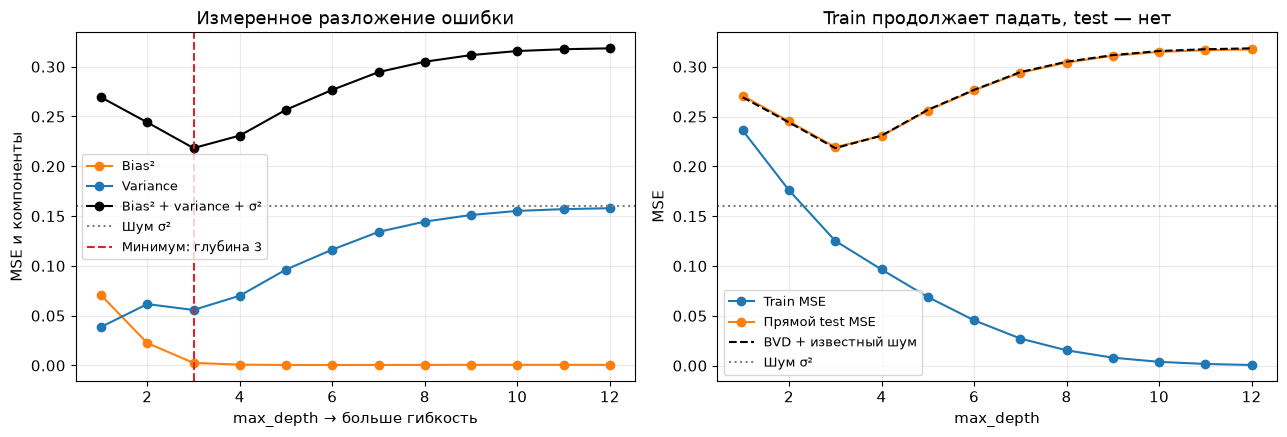

,bias2,variance,noise,expected_mse,train_mse,test_mse
depth,,,,,,
1,0.0707,0.0386,0.16,0.2693,0.2360,0.2709
2,0.0225,0.0616,0.16,0.2441,0.1760,0.2451
3,0.0026,0.0557,0.16,0.2183,0.1252,0.2193
4,0.0008,0.0700,0.16,0.2308,0.0965,0.2305
5,0.0004,0.0963,0.16,0.2567,0.0689,0.2560
6,0.0004,0.1163,0.16,0.2767,0.0455,0.2762
7,0.0005,0.1341,0.16,0.2946,0.0272,0.2939
8,0.0006,0.1444,0.16,0.3050,0.0154,0.3042
9,0.0006,0.1511,0.16,0.3116,0.0080,0.3109


Максимальное |test MSE − сумма BVD|: 0.0016


In [7]:
rng_tree = np.random.default_rng(2026)
B, n_train, n_grid = 300, 80, 300
sigma_tree = 0.4
depths = np.arange(1, 13)
x_grid = -1 + (np.arange(n_grid) + 0.5) * 2 / n_grid
f_grid = np.sin(np.pi * x_grid)
predictions = np.empty((len(depths), B, n_grid))
train_mse = np.empty((len(depths), B))
y_test = f_grid + rng_tree.normal(0, sigma_tree, size=(B, n_grid))
for b in range(B):
    x_train = rng_tree.uniform(-1, 1, size=(n_train, 1))
    y_train = np.sin(np.pi * x_train[:, 0]) + rng_tree.normal(0, sigma_tree, n_train)
    for k, depth in enumerate(depths):
        model = DecisionTreeRegressor(max_depth=int(depth), random_state=0)
        model.fit(x_train, y_train)
        predictions[k, b] = model.predict(x_grid[:, None])
        train_mse[k, b] = np.mean((model.predict(x_train) - y_train)**2)

rows = []
for k, depth in enumerate(depths):
    row = estimate_bvd(predictions[k], f_grid, sigma_tree**2)
    row.update(depth=depth, train_mse=train_mse[k].mean(),
               test_mse=np.mean((predictions[k] - y_test)**2))
    rows.append(row)
tree_results = pd.DataFrame(rows).set_index("depth")
best_depth = int(tree_results.expected_mse.idxmin())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
for key, label, color in [("bias2", "Bias²", "tab:orange"),
                          ("variance", "Variance", "tab:blue"),
                          ("expected_mse", "Bias² + variance + σ²", "black")]:
    ax.plot(depths, tree_results[key], "o-", label=label, color=color)
ax.axhline(sigma_tree**2, color="gray", ls=":", label="Шум σ²")
ax.axvline(best_depth, color="tab:red", ls="--", label=f"Минимум: глубина {best_depth}")
ax.set(title="Измеренное разложение ошибки", xlabel="max_depth → больше гибкость", ylabel="MSE и компоненты")
ax.legend(fontsize=9)
ax = axes[1]
ax.plot(depths, tree_results.train_mse, "o-", label="Train MSE")
ax.plot(depths, tree_results.test_mse, "o-", label="Прямой test MSE")
ax.plot(depths, tree_results.expected_mse, "--", color="black", label="BVD + известный шум")
ax.axhline(sigma_tree**2, color="gray", ls=":", label="Шум σ²")
ax.set(title="Train продолжает падать, test — нет", xlabel="max_depth", ylabel="MSE")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
display(tree_results.round(4))
print("Максимальное |test MSE − сумма BVD|:",
      round((tree_results.test_mse - tree_results.expected_mse).abs().max(), 4))

Слева компоненты получены из разных обученных деревьев, а не нарисованы как условная схема. Справа видно, почему минимизация train MSE не выбирает лучшую сложность: дерево может запоминать обучающий шум, но независимый тестовый шум предсказать невозможно.

Посмотрим на сами функции для мелкого дерева, глубины с минимальным оценённым риском и глубокого дерева. Цветная полоса — **средний прогноз ± одно стандартное отклонение между переобучениями**. Это не доверительный интервал среднего и не предиктивный интервал нового ответа; распределение прогнозов дерева не обязано быть нормальным.

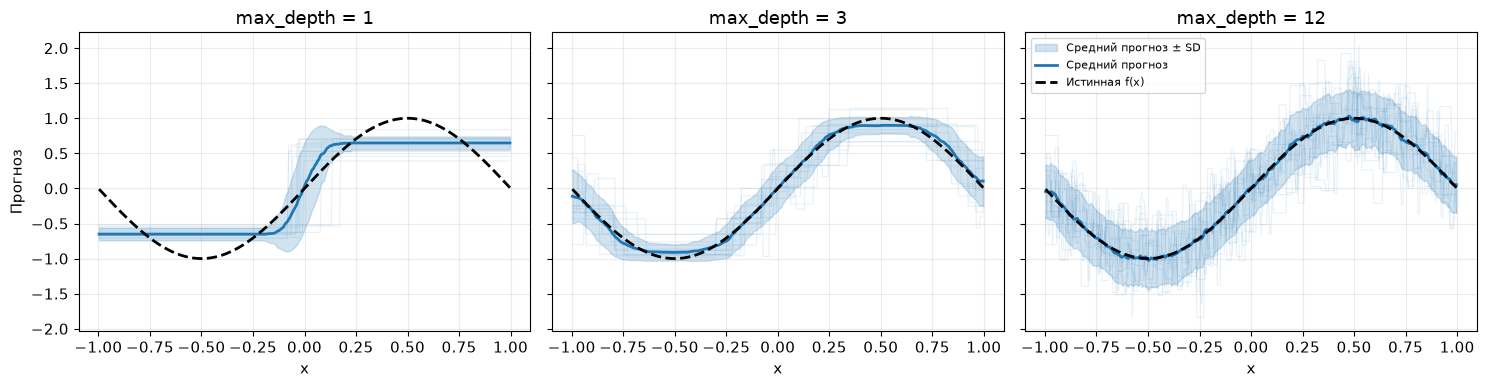

In [8]:
selected_depths = [1, best_depth, int(depths[-1])]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, depth in zip(axes, selected_depths):
    values = predictions[np.flatnonzero(depths == depth)[0]]
    mean, std = values.mean(axis=0), values.std(axis=0)
    ax.plot(x_grid, values[:12].T, color="tab:blue", alpha=0.10, linewidth=0.8)
    ax.fill_between(x_grid, mean - std, mean + std, color="tab:blue", alpha=0.20,
                    label="Средний прогноз ± SD")
    ax.plot(x_grid, mean, color="tab:blue", linewidth=2, label="Средний прогноз")
    ax.plot(x_grid, f_grid, color="black", ls="--", linewidth=2, label="Истинная f(x)")
    ax.set(title=f"max_depth = {depth}", xlabel="x")
axes[0].set_ylabel("Прогноз")
axes[-1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 10. Практические выводы и самопроверка

| Модель и условия | Смещение прогноза | Дисперсия прогноза | Чем управляем |
|---|---|---|---|
| OLS, правильная линейная модель, фиксированный полный ранг | $0$ | $\sigma^2x_0^TS^{-1}x_0$ | Признаки, размер выборки |
| Ridge, те же условия | $-\lambda x_0^TA_\lambda\beta$ | $\sigma^2x_0^TA_\lambda S A_\lambda x_0$ | $\lambda$ |
| Lasso, дополнительно $X^TX=nI$ и нормальный шум | $\sum_jx_{0j}(m_j-\beta_j)$ | $\sum_jx_{0j}^2(q_j-m_j^2)$ | $\alpha$ |
| Заранее заданные листья, фиксированный $X$ | $\bar f_L-f(x_0)$ | $\sigma^2/n_L$ | Размер листьев |
| Обучаемое дерево CART | $\mathbb E_D\hat f_D(x_0)-f(x_0)$ | $\operatorname{Var}_D\hat f_D(x_0)$ | Глубина, размер листа, pruning |

Для MSE нужно **возвести смещение в квадрат**, прибавить дисперсию и шум нового ответа. Ошибка коэффициентов и ошибка прогноза различаются: переход зависит от распределения тестовых признаков. Их простое суммирование в линейном эксперименте допустимо именно благодаря $\mathbb E[xx^T]=I$.

### Что делать в реальной задаче

1. Выбирать силу штрафа и сложность дерева по validation/CV; финальный test оставлять для однократной оценки выбранной процедуры. Подбор параметров — часть обучения, и его случайность тоже входит в BVD всей процедуры.
2. При высоком bias искать более подходящие признаки и модель, ослаблять чрезмерную регуляризацию. Одно увеличение числа наблюдений не исправит неверную форму модели.
3. При высокой variance собирать больше данных, усиливать регуляризацию или усреднять модели. Это направления диагностики, а не точное восстановление BVD по двум числам train/test.
4. Не ожидать нулевого test MSE при положительном условном шуме. Новые информативные признаки могут уменьшить $\operatorname{Var}(y\mid x)$, то есть изменить сам уровень «неустранимой» ошибки.

### Связь с ансамблями

Если $M$ моделей имеют одинаковые средние прогнозы, дисперсию $v$ и попарную корреляцию $\rho$, дисперсия их среднего равна

$$v_{ensemble}=v\left(\rho+\frac{1-\rho}{M}\right).$$

Усреднение сохраняет bias среднего базового алгоритма и уменьшает variance при $\rho<1$. Сильно коррелированные модели дают ограниченный выигрыш. В реальном Random Forest рандомизация и bootstrap могут менять и bias базовых деревьев; подробности — в [конспекте про случайный лес](randomforest.ipynb).

